In [1]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

import matplotlib.pyplot
import pandas
import seaborn

In [2]:
dataset = load_iris()

In [3]:
X = pandas.DataFrame(dataset['data'], columns = dataset['feature_names'])

In [4]:
X_train, X_test = train_test_split(X, test_size = 0.20)

In [5]:
model = Pipeline(
    steps= [
        ('scaler', StandardScaler()),
        ('clustering', KMeans(n_clusters = 3, init = 'random', max_iter = 500, random_state = 42))
    ]
)

In [6]:
result = model.fit(X_train).named_steps['clustering'].labels_

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

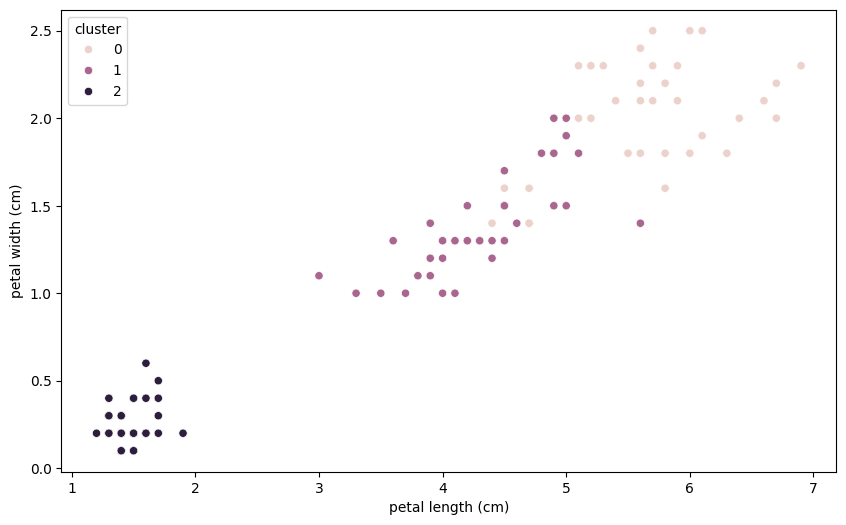

In [7]:
matplotlib.pyplot.figure(figsize = (10, 6))
X_plot = X_train.copy()
X_plot['cluster'] = result
seaborn.scatterplot(
    data = X_plot,
    x = 'petal length (cm)',
    y = 'petal width (cm)',
    hue = 'cluster'
)